In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
foldername = 'results/20250422/'
pickels = glob.glob(f'{foldername}/*pkl')

if len(pickels) > 1:
    df_list = []
    for file in pickels:
        df_list.append(pd.read_pickle(file))

    df = pd.concat(df_list)
    #df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [14]:
print(df.shape)
df.head()

(1816, 21)


,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",25820,"[563.0, 166.0, 180.0, 183.0]",0.992188,"[[620.0, 195.0]]",0.990134,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",729,25819.0,...,90.657384,"(620.0, 195.0)",185.067555,175.405151,115.667222,113.32173,219.256439,A-01,A-immo,1.25
1,"[[False, False, False, False, False, False, Fa...",26005,"[813.0, 527.0, 183.0, 181.0]",0.992188,"[[900.0, 555.0]]",0.990695,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",733,26005.0,...,90.981584,"(900.0, 555.0)",185.0,177.483795,115.625,113.72698,221.854744,A-01,A-immo,1.25
2,"[[False, False, False, False, False, False, Fa...",25190,"[1010.0, 450.0, 182.0, 177.0]",0.992188,"[[1060.0, 465.0]]",0.990635,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",723,25192.0,...,89.544548,"(1060.0, 465.0)",183.133831,174.359497,114.458644,111.930685,217.949371,A-01,A-immo,1.25
3,"[[False, False, False, False, False, False, Fa...",25949,"[562.0, 165.0, 360.0, 184.0]",0.984375,"[[660.0, 165.0]]",0.988077,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",733,25940.0,...,90.88357,"(660.0, 165.0)",185.809042,175.695496,116.130651,113.604462,219.61937,A-01,A-immo,1.25
4,"[[False, False, False, False, False, False, Fa...",25948,"[697.0, 527.0, 298.0, 412.0]",0.953125,"[[900.0, 525.0]]",0.990145,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",731,25943.0,...,90.881818,"(900.0, 525.0)",185.205292,177.01178,115.753307,113.602273,221.264725,A-01,A-immo,1.25


In [4]:
#df[(df.experiment == 'C-MES20-1h20')] = "C-MES10-1h20"
df.loc[df.experiment == 'C-MES20-1h20', 'experiment'] = 'C-MES10-1h20'

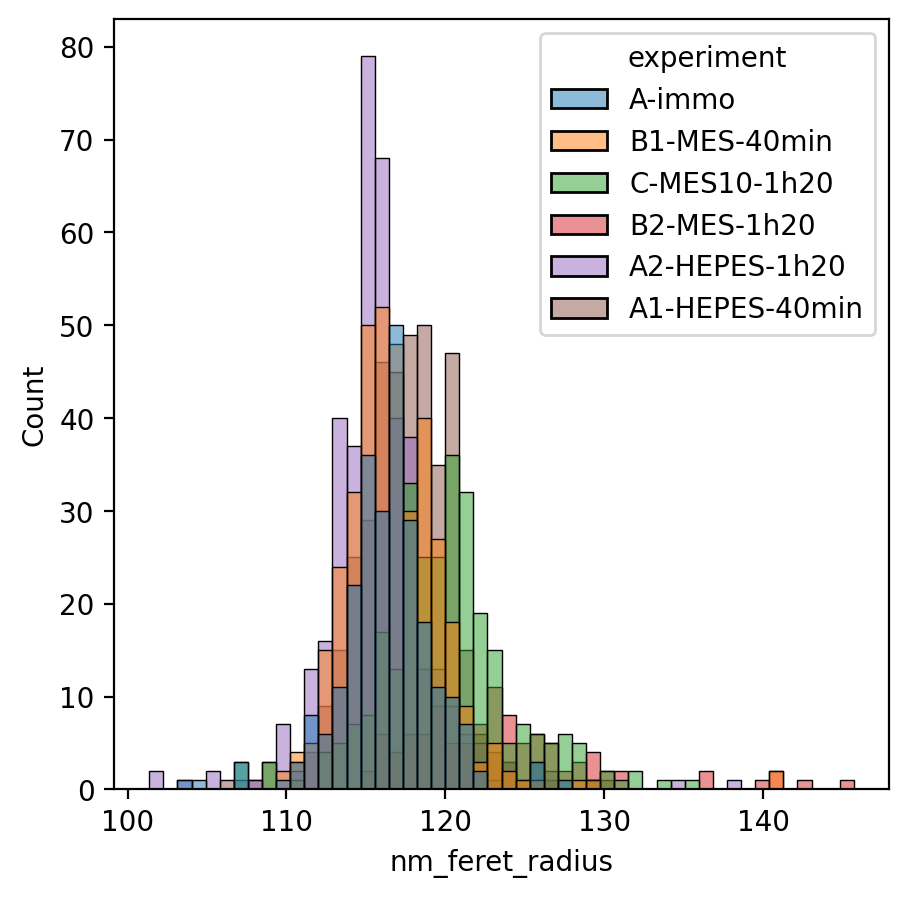

In [5]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [13]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
#exclusion_list = [ 'A1-04', 'A1-12', 'A1-17','A1-18','A1-19', 'A2-08', 'A3-15', 'A3-16', 'A3-17', 'A3-20'] #20250324
exclusion_list = [] #20250324-sam2

In [14]:
df_exluded = df[~df['img_name'].isin(exclusion_list)]
df_exluded.shape

(1816, 21)

In [15]:
df_exluded = df_exluded.query("circularity > 0.65")
df_exluded.shape

(1816, 21)

In [16]:
df_exluded['hough_radius'] = df_exluded.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

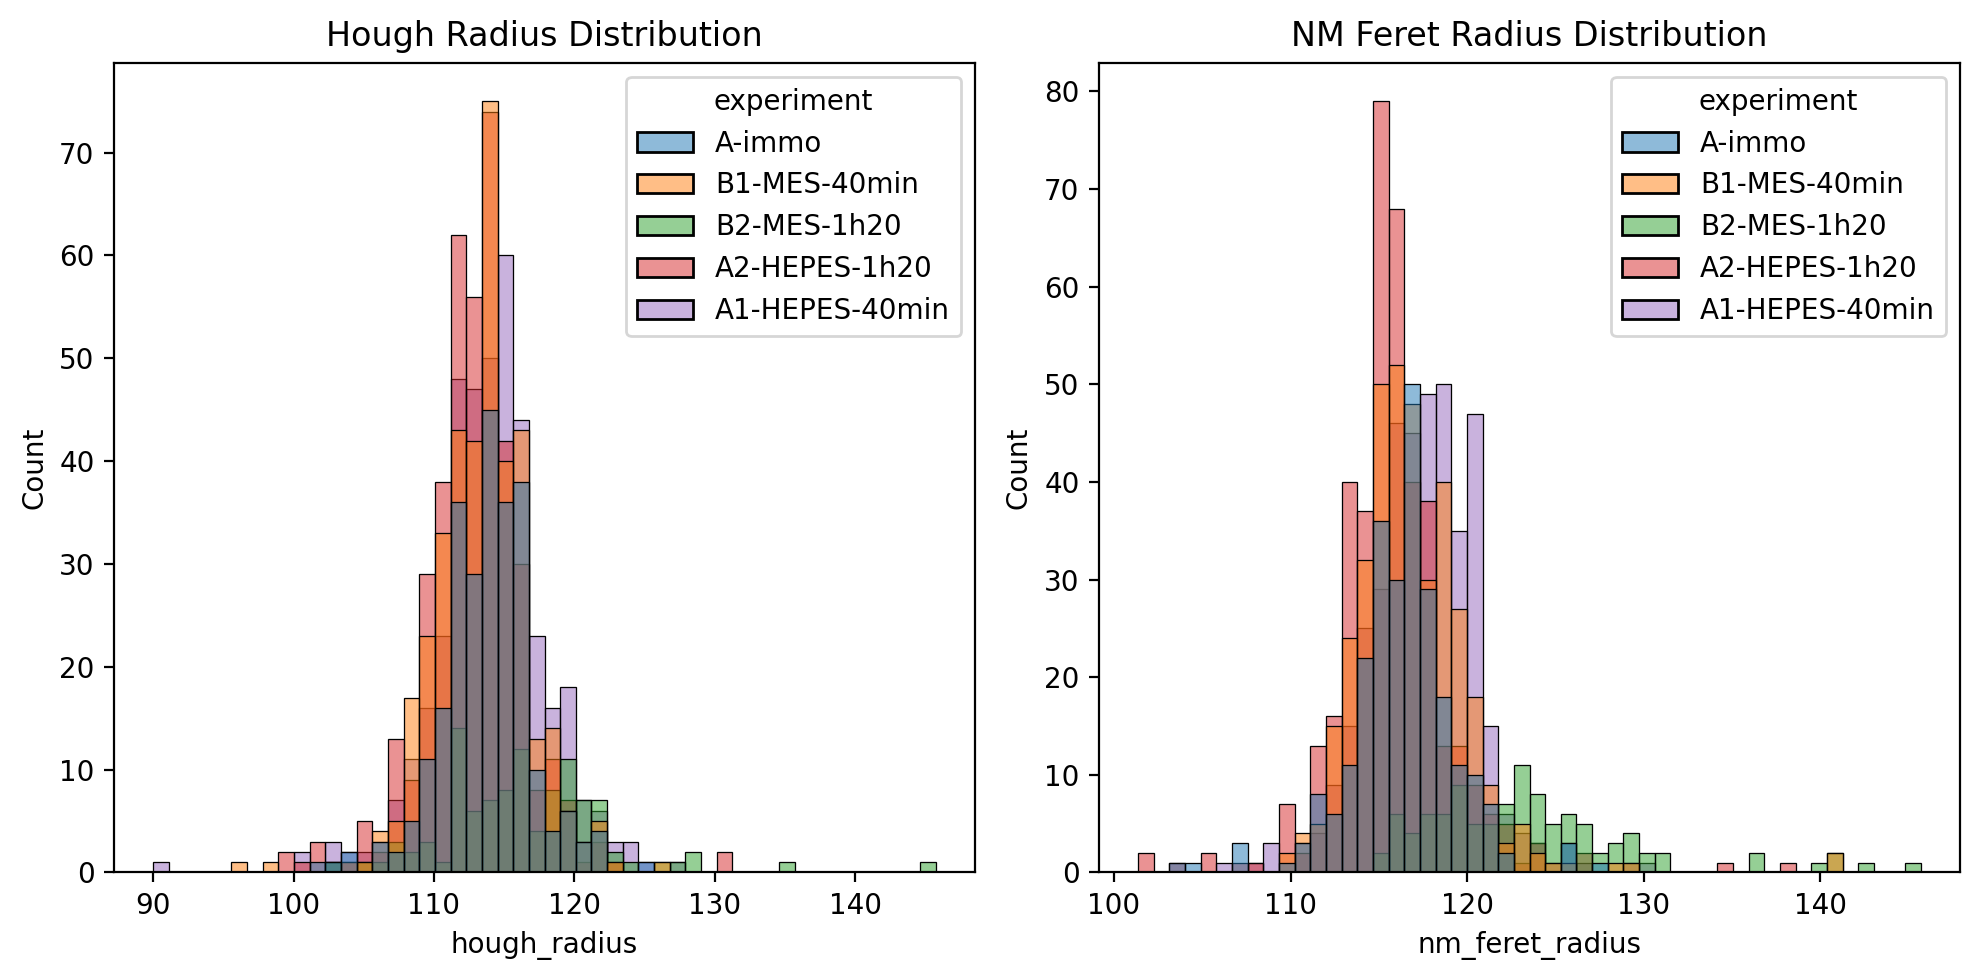

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=df_exluded.dropna(), x='hough_radius', hue='experiment', bins=50, ax=axes[0])
axes[0].set_title("Hough Radius Distribution")

sns.histplot(data=df_exluded.dropna(), x='nm_feret_radius', hue='experiment', bins=50, ax=axes[1])
axes[1].set_title("NM Feret Radius Distribution")
plt.tight_layout()

# Save the figure
plt.savefig(f'{foldername}/unfiltered_measurements')
plt.show()

In [18]:
#filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 

def filter_multiple(df, filters):
    '''quantile filtering for multiple filters'''
    for filter_quantity in filters:
        if filter_quantity in df.columns:
            q5, q95 = df[filter_quantity].quantile([0.05, 0.95])
            df = df[(df[filter_quantity] < q95) & (df[filter_quantity] > q5)]
        else:
            print(f'{filter_quantity} not found in dataframe')
    return df

df_filtered = filter_multiple(df_exluded, ['nm_feret_radius', 'hough_radius'])
df_filtered.shape

(1465, 22)

In [20]:
df_filtered.experiment.unique()

array(['A-immo', 'B1-MES-40min', 'C-MES10-1h20', 'B2-MES-1h20',
       'A2-HEPES-1h20', 'A1-HEPES-40min'], dtype=object)

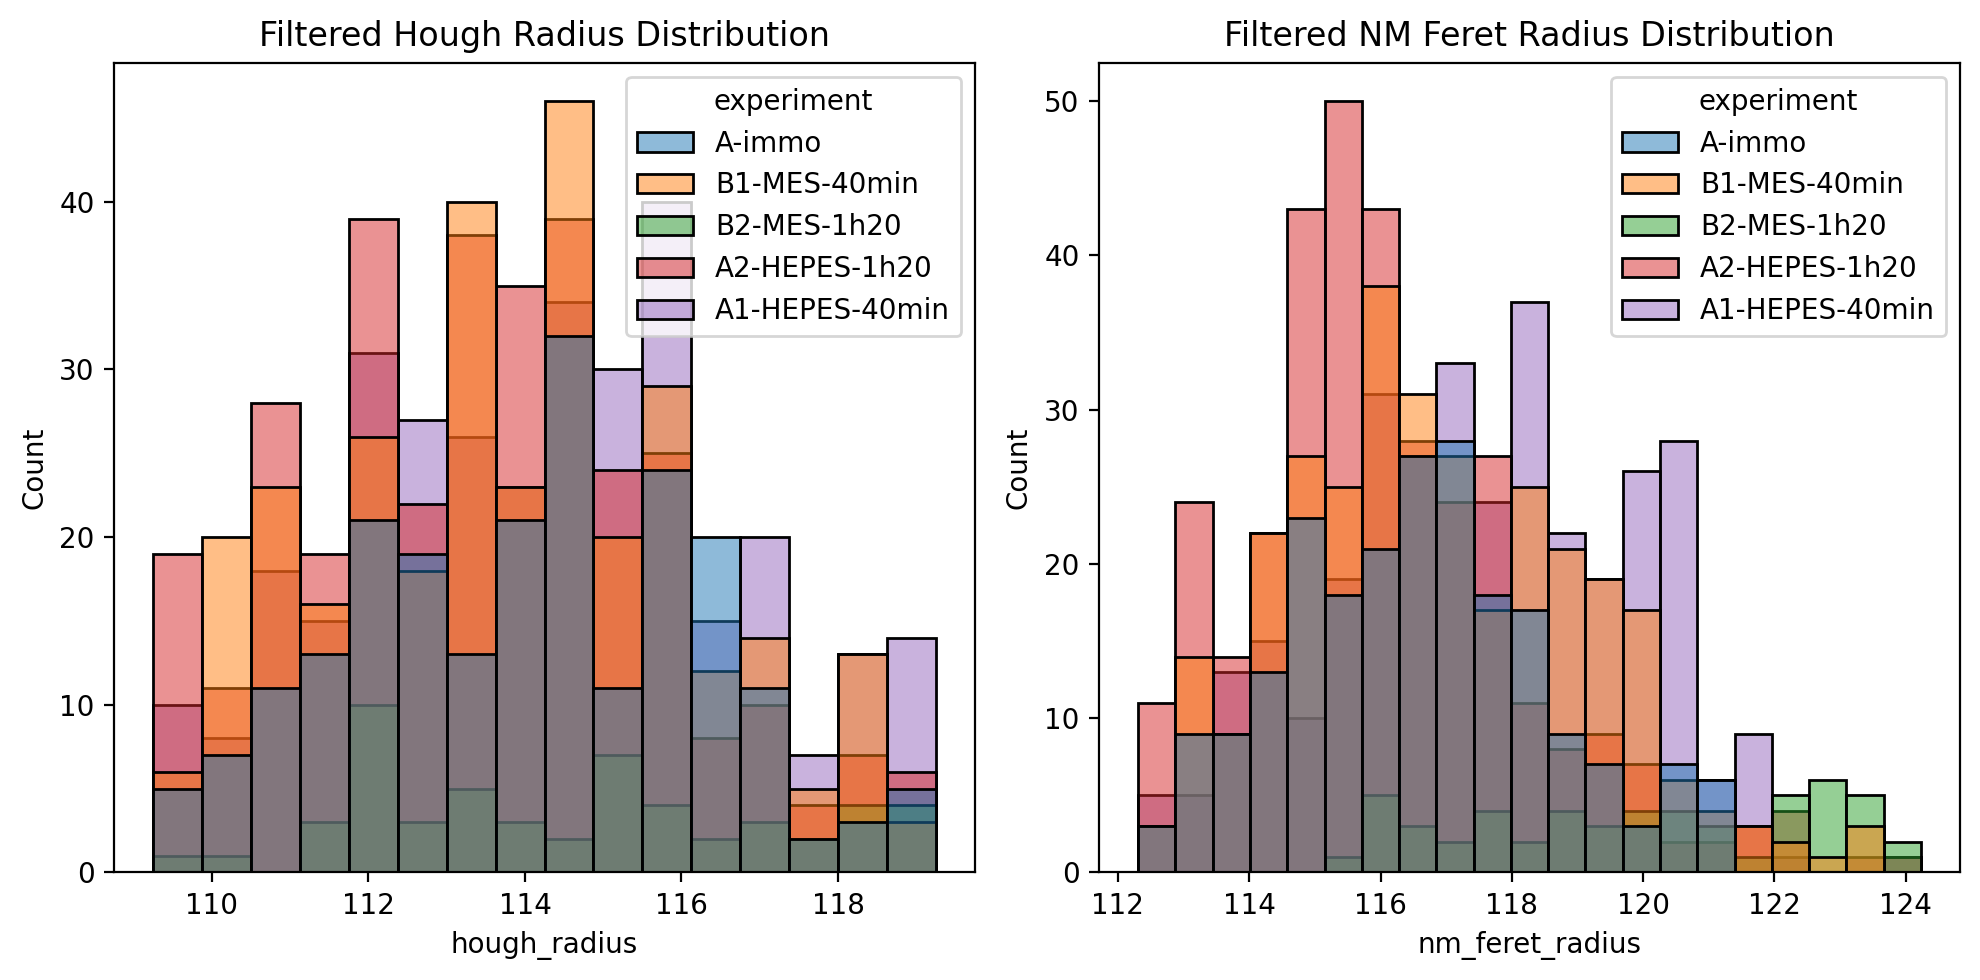

In [19]:
plot_df = df_filtered.dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=plot_df, x='hough_radius', hue='experiment', ax=axes[0])
axes[0].set_title("Filtered Hough Radius Distribution")

sns.histplot(data=plot_df, x='nm_feret_radius', hue='experiment', ax=axes[1])
axes[1].set_title("Filtered NM Feret Radius Distribution")

plt.tight_layout()

plt.savefig(f'{foldername}/filtered_particle_measurements')
plt.show()


<Figure size 1000x1000 with 0 Axes>

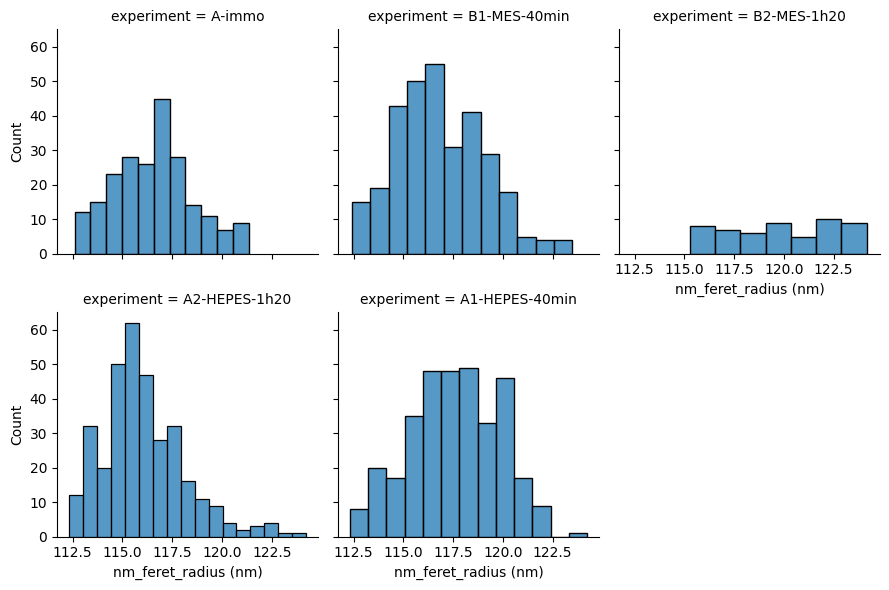

In [21]:
filter_quantity = 'nm_feret_radius'

plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [23]:
df_filtered['avg'] = (df_filtered.hough_radius + df_filtered.nm_feret_radius)/2

In [24]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=['hough_radius', 'nm_feret_radius', 'avg'])
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

hough_radius                                                        \
experiment       A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min B2-MES-1h20   
0                113.75         113.75        114.25       113.00      114.50   
1                112.75         116.00        114.50       111.50      113.75   
2                110.00         115.25        114.00       116.25      117.00   
3                109.75         113.00        113.75       118.50      112.00   
4                116.00         117.25        114.75       113.00      118.25   

                        nm_feret_radius                               \
experiment C-MES10-1h20          A-immo A1-HEPES-40min A2-HEPES-1h20   
0                115.25      115.667222     119.193252    112.974693   
1                115.50      115.625000     117.813743    117.526593   
2                112.50      114.458644     118.651275    116.734541   
3                119.00      116.130651     119.327543    114.976220   
4                119.25      115.753307     121.006521    118.547525   

                                                         avg                 \
experiment B1-MES-40min B2-MES-1h20 C-MES10-1h20      A-immo A1-HEPES-40min   
0            115.874730  119.193252   118.192772  114.708611     116.471626   
1            116.150831  122.758019   118.567294  114.187500     116.906872   
2            117.010283  118.257201   120.522949  112.229322     116.950637   
3            120.125260  123.015497   121.328905  112.940326     116.163771   
4            119.176864  122.812102   120.471081  115.876654     119.128261   

                                                                
experiment A2-HEPES-1h20 B1-MES-40min B2-MES-1h20 C-MES10-1h20  
0             113.612346   114.437365  116.846626   116.721386  
1             116.013296   113.825416  118.254010   117.033647  
2             115.367271   116.630141  117.628601   116.511475  
3             114.363110   119.312630  117.507748   120.164452  
4             116.648762   116.088432  120.531051   119.860540

In [25]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

hough_radius                                                        \
experiment       A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min B2-MES-1h20   
count        218.000000     331.000000    334.000000   314.000000   54.000000   
mean         113.974771     114.219789    113.417976   113.763089  114.550926   
std            2.188798       2.408050      2.206389     2.274247    2.603689   
min          109.500000     109.250000    109.250000   109.250000  109.250000   
25%          112.250000     112.500000    111.750000   111.986000  112.250000   
50%          114.000000     114.500000    113.250000   113.750000  114.500000   
75%          115.687500     115.750000    114.937500   115.250000  116.437500   
max          119.250000     119.250000    119.250000   119.250000  119.250000   

                        nm_feret_radius                               \
experiment C-MES10-1h20          A-immo A1-HEPES-40min A2-HEPES-1h20   
count        214.000000      218.000000     331.000000    334.000000   
mean         114.656532      116.577444     117.570571    116.054676   
std            2.327602        1.963251       2.237418      2.085012   
min          109.267990      112.597180     112.308865    112.327994   
25%          112.750000      115.022076     116.033064    114.741557   
50%          114.500000      116.634110     117.554841    115.726307   
75%          116.500000      117.650751     119.316085    117.200410   
max          119.415993      121.353049     124.225727    124.230444   

                                                         avg                 \
experiment B1-MES-40min B2-MES-1h20 C-MES10-1h20      A-immo A1-HEPES-40min   
count        314.000000   54.000000   214.000000  218.000000     331.000000   
mean         116.879712  119.974516   119.149504  115.276107     115.895180   
std            2.219645    2.657757     2.492695    1.873249       2.060994   
min          112.418373  115.284973   112.719342  111.528823     110.793344   
25%          115.220577  117.468413   117.530332  113.764527     114.383846   
50%          116.640808  119.799637   119.548339  115.360408     115.960056   
75%          118.434202  122.455716   120.941941  116.498963     117.375045   
max          123.492472  124.153383   124.514683  120.132248     120.486331   

                                                                
experiment A2-HEPES-1h20 B1-MES-40min B2-MES-1h20 C-MES10-1h20  
count         334.000000   314.000000   54.000000   214.000000  
mean          114.736326   115.321401  117.262721   116.903018  
std             1.869213     1.934302    2.133672     2.044770  
min           111.197858   111.459187  113.250034   111.937666  
25%           113.400361   114.036335  115.572092   115.578828  
50%           114.612129   115.227788  117.568175   117.020774  
75%           115.927687   116.746372  118.839152   118.507057  
max           120.616230   121.062500  121.436836   120.891764

In [26]:
method =  'hough_radius' 
method = 'nm_feret_radius' 
#method = 'avg' 


analysis_df = analyze_samples(experiment_df[method], 'A-immo', alpha=0.01)
#analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis_{method}.xlsx')
analysis_df

,A1-HEPES-40min,A2-HEPES-1h20,B1-MES-40min,B2-MES-1h20,C-MES10-1h20
thickness,0.993127,-0.522768,0.302269,3.397073,2.57206
CI_lower,0.52482,-0.975851,-0.17008,2.375879,2.012685
CI_upper,1.461433,-0.069684,0.774617,4.418267,3.131435
p_value,0.0,0.002991,0.098621,0.0,0.0
significance,Significant,Significant,Not significant,Significant,Significant
significance_level,99.5,99.5,99.5,99.5,99.5
SEM,0.18112,0.175204,0.182677,0.385343,0.216138
DOF,504.353523,483.386121,500.031122,67.992172,404.252533
N_sample,331,334,314,54,214
N_ref,218,218,218,218,218


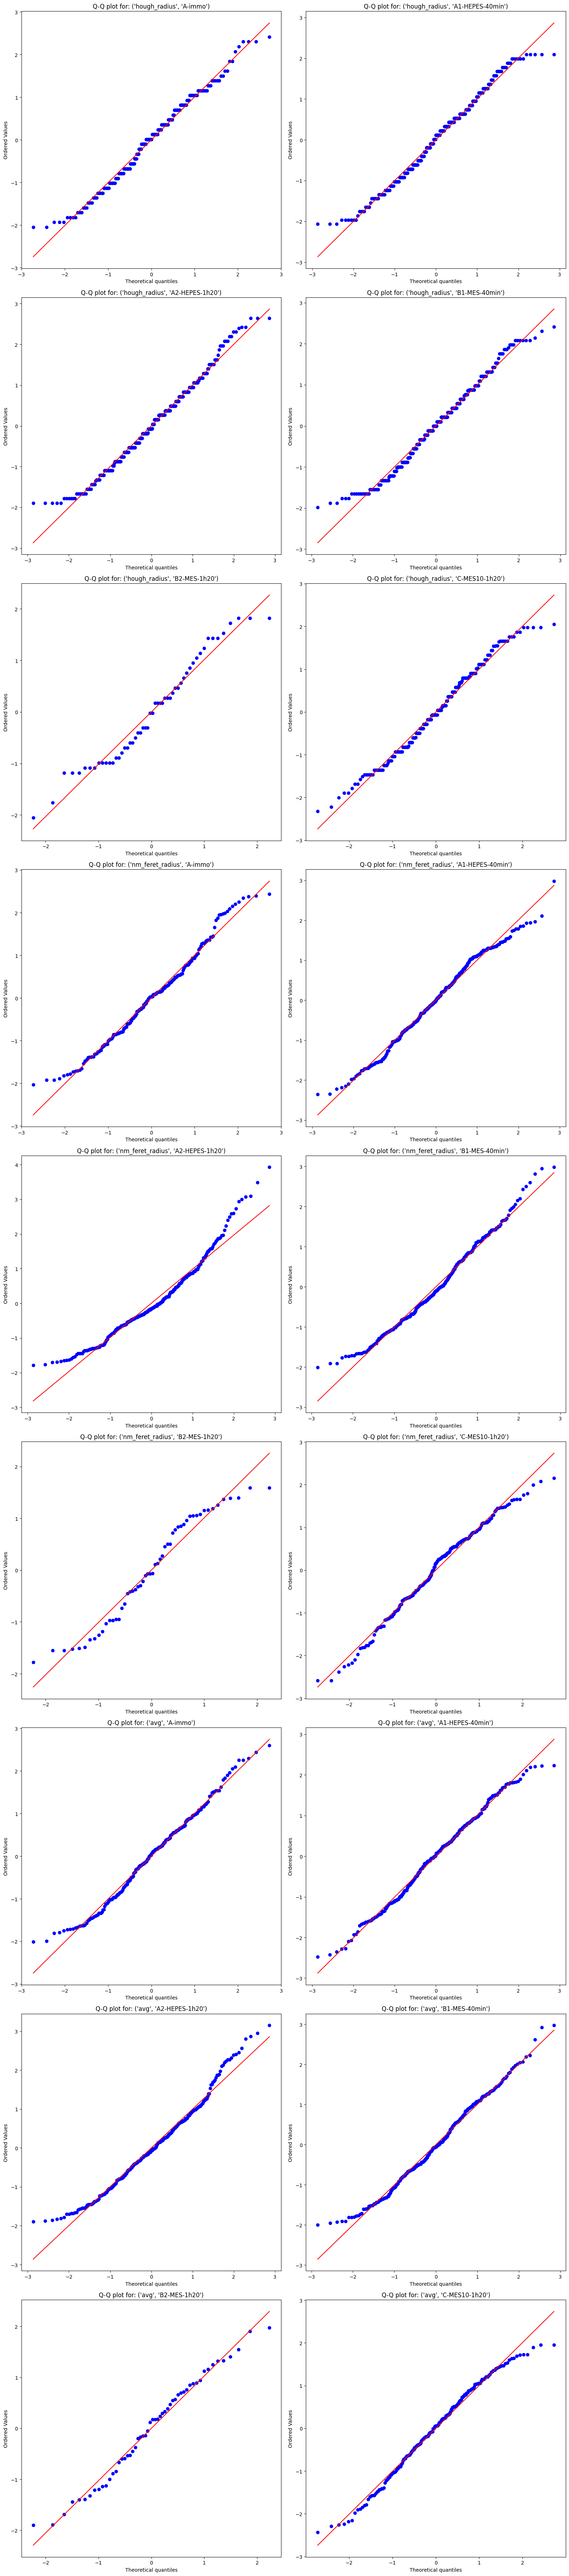

<Figure size 640x480 with 0 Axes>

In [27]:
plot_quantiles(experiment_df, foldername)
